5.6 Activity:Iris DataSet Exploration
Use Numpy + Pandas to analyze the dataset and visualize pairwise relationship with seaborn 

In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [4]:
#load iris dataset
iris = load_iris(as_frame = True)

In [5]:
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [6]:
print(iris)

{'data':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns], 'target': 0      0
1      0
2 

In [7]:
df = iris.frame

In [8]:
print(type(df))

<class 'pandas.DataFrame'>


In [9]:
df.shape

(150, 5)

In [8]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

In [10]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [12]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [13]:
print(enumerate(iris.target_names))

In [14]:
target_names = dict(enumerate(iris.target_names))
print(target_names)

{0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


In [17]:
df["Species"] = df["target"].map(target_names)

In [18]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [17]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [20]:
#quick pandas inspection
print("\n Shape: ", df.shape)
print("-"*50)
print("\n Info:")
print(df.info())
print("-"*50)
print("\n Describe (numeric):")
print(df.describe())


 Shape:  (150, 6)
--------------------------------------------------

 Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   Species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None
--------------------------------------------------

 Describe (numeric):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000       

In [19]:
#convert to numpy arrays
feature_cols = iris.feature_names
x = df[feature_cols]
y = df["target"]

In [25]:
print(type(x))


<class 'pandas.DataFrame'>


In [26]:
print(type(y))

<class 'pandas.Series'>


In [27]:
print(x)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [28]:
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64


In [20]:
x = x.to_numpy()
y = y.to_numpy()

In [21]:
#numpy stats (column-wise): mean,std
col_means = x.mean(axis=0)
col_stds = x.std(axis=0, ddof=0) #population std (ddof=0)
print("\n Numpy column means: ", col_means)
print("numpy column stds: ", col_stds)


 Numpy column means:  [5.84333333 3.05733333 3.758      1.19933333]
numpy column stds:  [0.82530129 0.43441097 1.75940407 0.75969263]


In [22]:
print("missing values in the dataset")
print(df.isnull().sum())

missing values in the dataset
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
Species              0
dtype: int64


In [35]:
df.groupby("Species")[feature_cols].mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


Text(0.5, 0.98, 'Pairwise feature relationship')

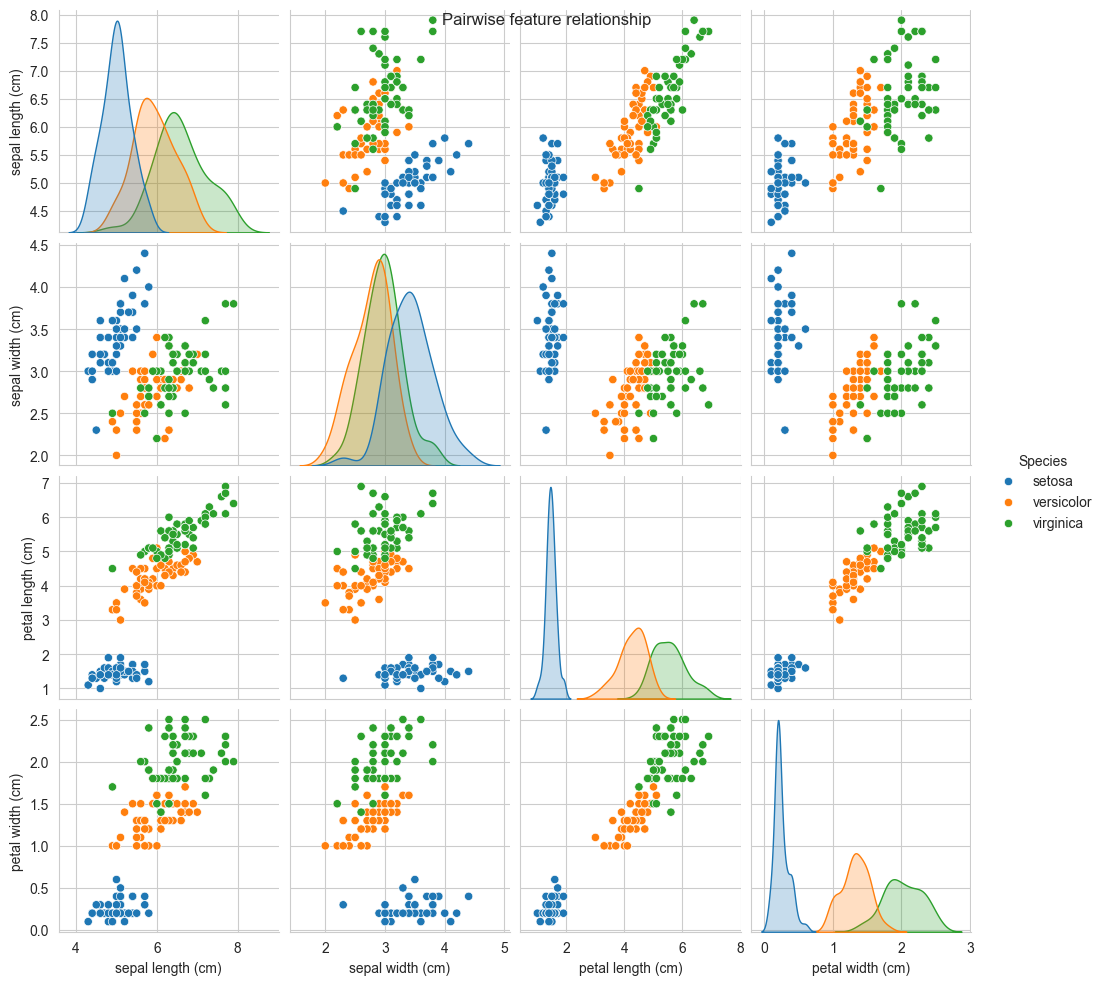

In [23]:
#pairplot with seaborn
sns.set_style("whitegrid")
sns.pairplot(df[feature_cols + ["Species"]], hue = "Species", diag_kind = "kde")
plt.suptitle("Pairwise feature relationship")

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


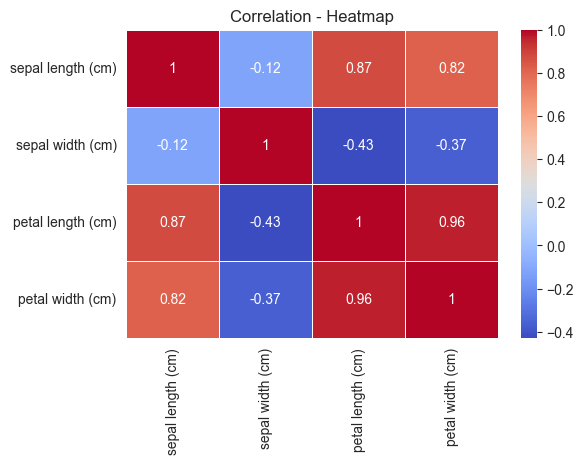

In [41]:
#correlation heatmap
corr = df[feature_cols].corr(numeric_only=True)
print(corr)
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidth = 0.5)
plt.title("Correlation - Heatmap")
plt.show()

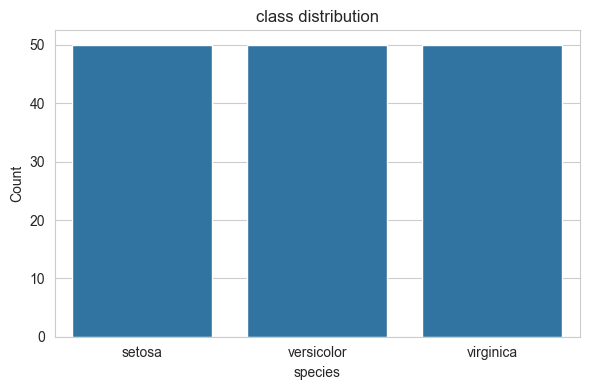

In [42]:
#Class distribution bar chart 
plt.figure(figsize=(6,4))
sns.countplot(x="Species", data=df)
plt.title("class distribution")
plt.xlabel("species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
          